In [ ]:
from problems.waveguide import WaveguideProblem, Clean
from problems.waveguide.base import SerialProblem
import numpy as np
from problems.waveguide.base import Assemblers
import matplotlib.pyplot as plt 
from trefftz.dg.fluxes import FluxType
from problems.waveguide.RHS_types import RHS_type
from trefftz.dg.basis import LinearlySpacedBasis, WaveguideTayloredBasis

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000515785s, CPU 0.000609s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.000673909s, CPU 0.000823s)
Info    : 14 nodes 30 elements


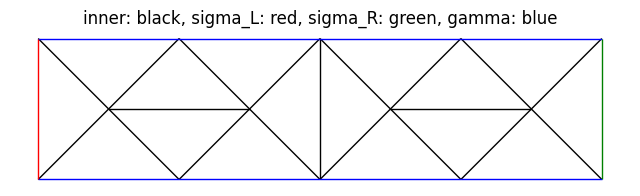

In [15]:
#waveguide = Waveguide.CreateClean(verbose=True, R=5, lc = 0.1, k=8.)
waveguide = Clean(verbose=True, R=2, lc = 1.)
waveguide.plot()

In [16]:
problem = SerialProblem(domain=waveguide, N_theta=10, k=10, NtD_modes=2, assembler=Assemblers.serial)

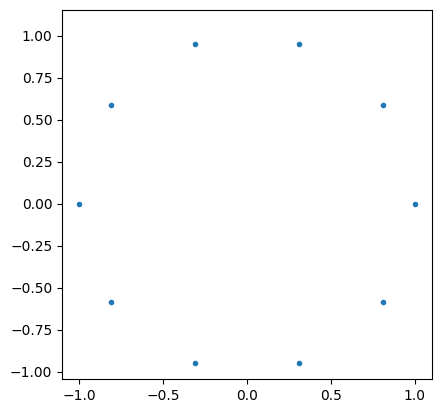

In [17]:
problem.basis.plot_directions()

In [ ]:
problem.basis = WaveguideTayloredBasis(problem.domain.mesh.n_triangles, problem.domain.H, problem.k)

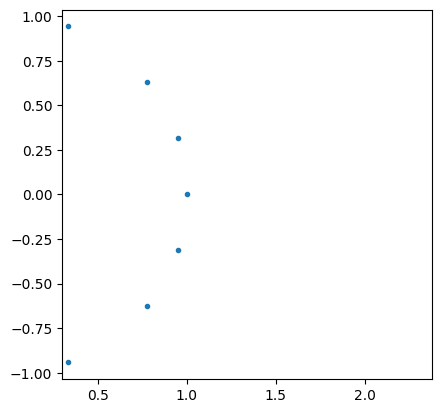

In [19]:
problem.basis.plot_directions()

In [20]:
problem.basis.N_theta

7

In [21]:
regions = waveguide.regions
list(regions)

[<WaveguideRegions.OMEGA: 0>,
 <WaveguideRegions.GAMMA: 1>,
 <WaveguideRegions.SIGMA_L: 3>,
 <WaveguideRegions.SIGMA_R: 4>,
 <WaveguideRegions.SIGMA: 2>,
 <WaveguideRegions.D_OMEGA: 5>]

In [22]:
list(FluxType)

[<FluxType.TRANSMISSION: 0>,
 <FluxType.SOUNDHARD: 1>,
 <FluxType.SOUNDSOFT: 2>,
 <FluxType.RADIATING: 3>,
 <FluxType.DIRICHLET: 4>,
 <FluxType.NEUMANN: 5>]

In [23]:
boundary_conditions = {regions.GAMMA: FluxType.SOUNDHARD,
                       regions.SIGMA_L: FluxType.RADIATING,
                       regions.SIGMA_R: FluxType.RADIATING}

In [25]:
n = 0
problem.assemble(RHS=RHS_type.MODE, RHS_params={"t": n})

no boundary conditions specified, use .set_boundary_conditions


In [26]:
problem.set_boundary_conditions(boundary_conditions)

In [27]:
for key in problem.stabilizing_parameters.keys():
    problem.stabilizing_parameters[key] = 0.5



In [29]:
n = 0
problem.assemble(RHS=RHS_type.MODE, RHS_params={"t": n})

In [30]:
problem.basis.N_DOF

112

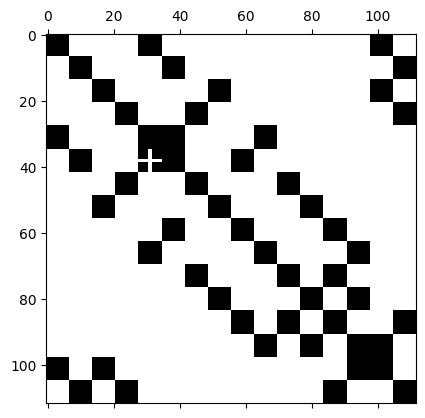

In [31]:
if problem.basis.N_DOF < 5000:
    A = problem.A
    plt.spy(A.toarray())

In [32]:
problem.domain.mesh.triangles[5]

np.void(([-5.504707800696451e-12, 0.0], [5.504707800696451e-12, 1.0], [-0.5000000000041388, 0.49999999999722666], [-0.16666666666804625, 0.4999999999990755], 0.2500000000020694), dtype=[('A', '<f8', (2,)), ('B', '<f8', (2,)), ('C', '<f8', (2,)), ('M', '<f8', (2,)), ('area', '<f8')])

In [33]:
u = problem.solve()


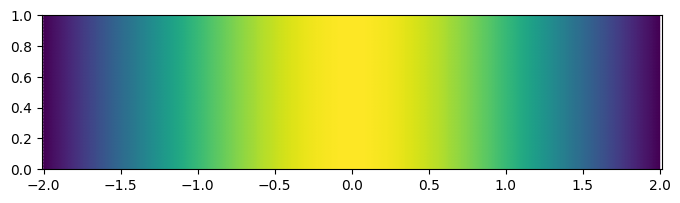

In [34]:
problem.plot_trefftz_function(u)

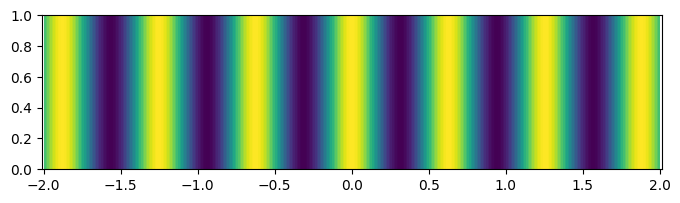

In [35]:
problem.plot_mode(n=n)

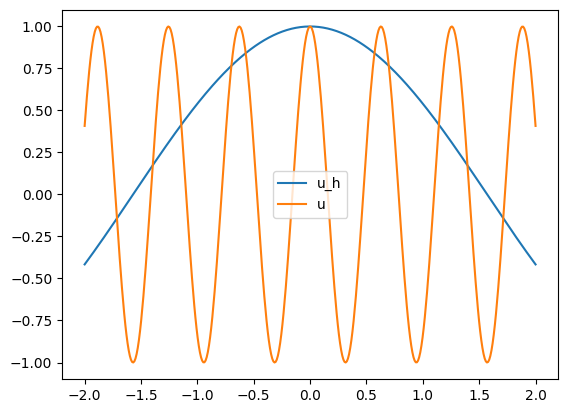

In [36]:
x = np.linspace(-waveguide.R, waveguide.R,400)
y = np.full_like(x, fill_value=0.2)
plt.plot(x,np.real(u(x,y)), label="u_h")
plt.plot(x,np.real(problem.mode(n=n)(x, y)), label="u")
plt.legend()


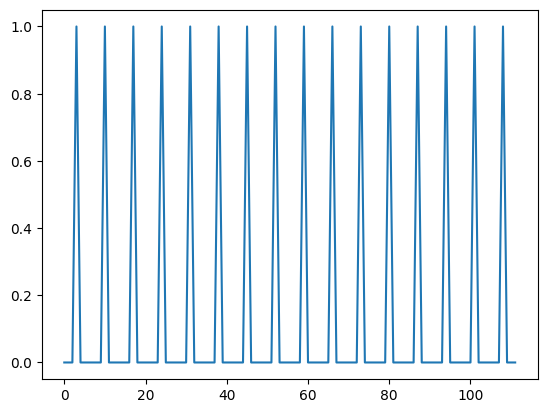

In [37]:
plt.plot(np.real(u.coefficients))

In [39]:
n=3
problem.assembleRHS(RHS=RHS_type.MODE, RHS_params={"t": n})

In [40]:
u = problem.solve()

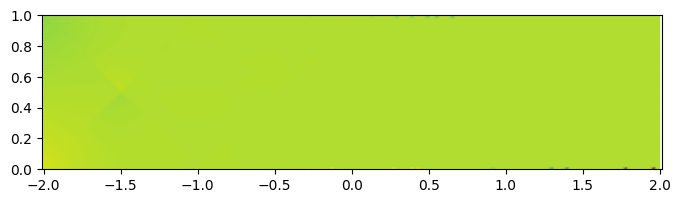

In [41]:
problem.plot_trefftz_function(u)

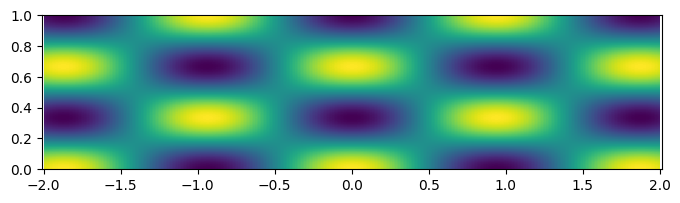

In [42]:
problem.plot_mode(n=n)

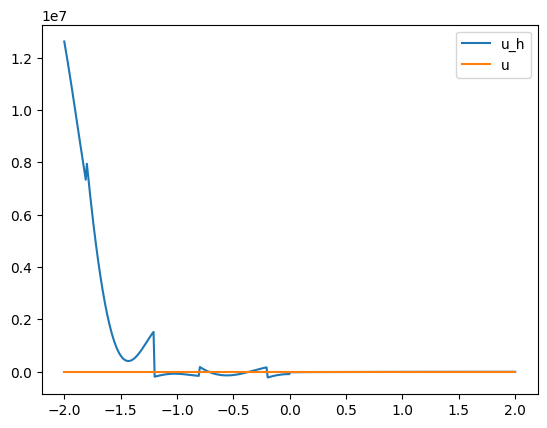

In [43]:
x = np.linspace(-waveguide.R, waveguide.R,400)
y = np.full_like(x, fill_value=0.2)
plt.plot(x,np.real(u(x,y)), label="u_h")
plt.plot(x,np.real(problem.mode(n=n)(x, y)), label="u")
plt.legend()